In [1]:
###############################
# Notebook 08 – Residuenanalyse
# Projekt: Preisbewertung NL
###############################

import pandas as pd
import joblib
import statsmodels.api as sm


In [2]:
# Dateien laden
X_ml = pd.read_csv("../data_clean/X_ml.csv")
y_ml = pd.read_csv("../data_clean/y_ml.csv")
X_test = pd.read_csv("../data_clean/X_test.csv")
y_test = pd.read_csv("../data_clean/y_test.csv")

# Modelle laden
rf = joblib.load("../data_clean/rf_model.pkl")
model_ext = joblib.load("../data_clean/ols_model.pkl")

# OLS-Test
X_test_ols = sm.add_constant(X_test, has_constant='add')


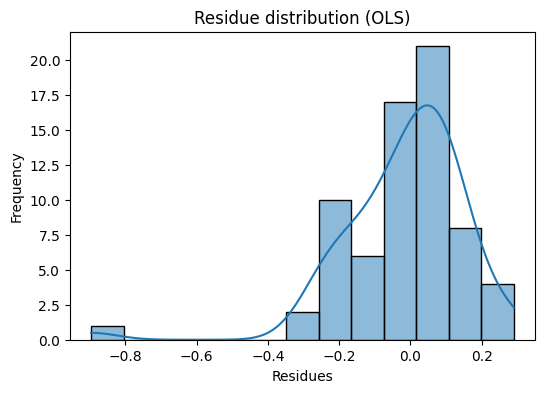

In [3]:
###########################################
# 8.1. Residuen berechnen und visualisieren
###########################################

import matplotlib.pyplot as plt
import seaborn as sns

# OLS-Vorhersagen
y_pred_ols = model_ext.predict(X_test_ols)

# Residuen berechnen
residuals = y_test.values.ravel() - y_pred_ols

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residue distribution (OLS)")
plt.xlabel("Residues")
plt.ylabel("Frequency")
plt.show()


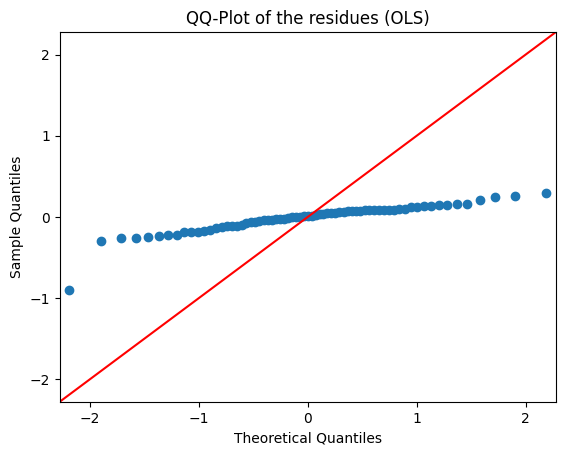

In [4]:
######################################
# 8.2. QQ‑Plot (Normalverteilungstest)
#####################################

sm.qqplot(residuals, line='45')
plt.title("QQ-Plot of the residues (OLS)")
plt.show()


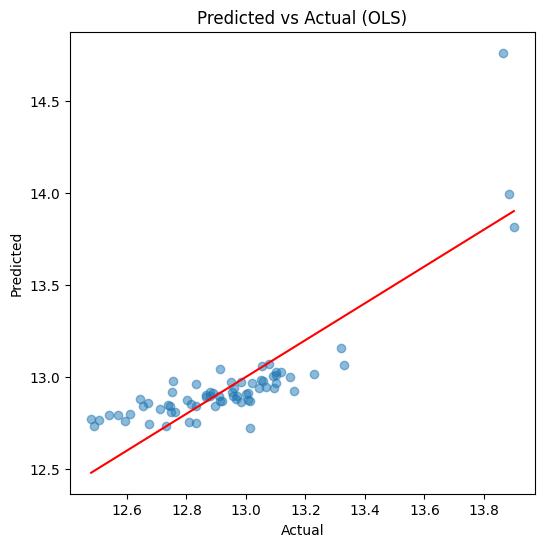

In [5]:
#################################
# 8.3. Predicted vs. Actual (OLS)
#################################

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_ols, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual (OLS)")
plt.show()


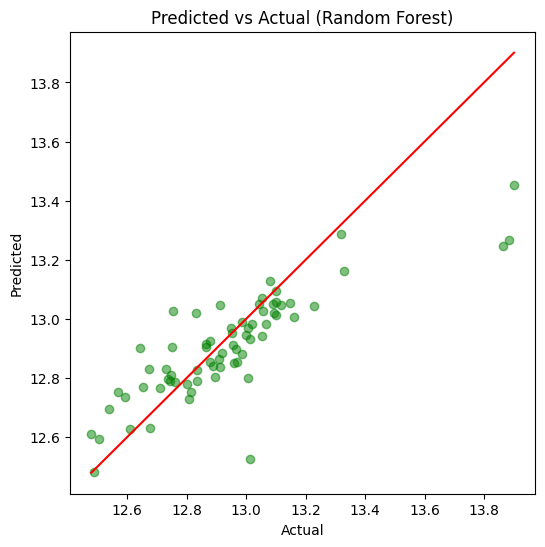

In [6]:
############################################
# 8.4. Predicted vs. Actual (Random-Forrest)
############################################

# RF-Vorhersagen
y_pred_rf = rf.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual (Random Forest)")
plt.show()


In [7]:
########################
# 8.5. Overfitting-Check
########################

from sklearn.metrics import r2_score

r2_train_rf = r2_score(y_ml, rf.predict(X_ml))
r2_test_rf = r2_score(y_test, y_pred_rf)

print("RF Train R²:", r2_train_rf)
print("RF Test R²:", r2_test_rf)

RF Train R²: 0.8465305756447796
RF Test R²: 0.6473890542505858


In [8]:
####################################################################
# 8.6. Änderung Provinz Zeeland (statt Provinz Drenthe) als Referenz
####################################################################

import pandas as pd
import statsmodels.api as sm

# Basisdaten laden
df = pd.read_csv("../data_clean/df_model_prepared.csv")

df = df.astype({col: int for col in df.columns if df[col].dtype == bool})

# Object-Spalten entfernen
df = df.drop(columns=["gemeentenaam"], errors="ignore")

# Provinz-Dummies erzeugen (falls noch nicht vorhanden)
if "province" in df.columns:
    df = pd.get_dummies(df, columns=["province"], drop_first=True)

# Feature-Liste OHNE longitude/latitude
features = [
    'income_mean',
    'woz_mean',
    'log_density',
    'migration_per_1000',
    'employment_rate',
    'labor_participation_net',
    'province_Flevoland',
    'province_Fryslân',
    'province_Gelderland',
    'province_Groningen',
    'province_Limburg',
    'province_Noord-Brabant',
    'province_Noord-Holland',
    'province_Overijssel',
    'province_Utrecht',
    'province_Zuid-Holland',
    'ratio_price_model',
    'ratio_stock',
    'woningvoorraad_total',
    'pipeline_total',
    'new_build_stock_tot',
    'households'
]

# Nur Features verwenden, die wirklich existieren
features = [f for f in features if f in df.columns]

# X und y definieren
X = df[features]
X = sm.add_constant(X)

y = df["log_price_total"]

# OLS schätzen
model_clean = sm.OLS(y, X).fit()
print(model_clean.summary())


                            OLS Regression Results                            
Dep. Variable:        log_price_total   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                     184.5
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          1.67e-166
Time:                        17:27:41   Log-Likelihood:                 490.27
No. Observations:                 341   AIC:                            -934.5
Df Residuals:                     318   BIC:                            -846.4
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [9]:
#############################################
# 8.7.1 Änderung 'nicht_randstad' als Referenz
#############################################

import pandas as pd
import statsmodels.api as sm

# Basisdaten laden
df = pd.read_csv("../data_clean/df_model_prepared.csv")
df_geo = pd.read_csv("../data_clean/df_geo_2023.csv")

# 1. Alte Provinz-Dummies entfernen (falls vorhanden)
df = df.drop(columns=[col for col in df.columns if col.startswith("province_")], errors="ignore")

# 2. province reinholen
df = df.merge(
    df_geo[["municipality_code", "province"]],
    on="municipality_code",
    how="left"
)

# 3. Neue Provinz-Dummies erzeugen
df = pd.get_dummies(df, columns=["province"], drop_first=False)

# 4. Zeeland entfernen (Referenzkategorie)
df = df.drop(columns=["province_Zeeland"], errors="ignore")

# 5. bool → int
for col in df.columns:
    if df[col].dtype == bool:
        df[col] = df[col].astype(int)

# 6. Feature-Liste
features = [
    'income_mean',
    'woz_mean',
    'log_density',
    'migration_per_1000',
    'employment_rate',
    'labor_participation_net',
    'is_randstad',
    'province_Flevoland',
    'province_Fryslân',
    'province_Gelderland',
    'province_Groningen',
    'province_Limburg',
    'province_Noord-Brabant',
    'province_Noord-Holland',
    'province_Overijssel',
    'province_Utrecht',
    'province_Zuid-Holland',
    'ratio_price_model',
    'ratio_stock',
    'woningvoorraad_total',
    'pipeline_total',
    'new_build_stock_tot',
    'households'
]

# Nur existierende Spalten verwenden
features = [f for f in features if f in df.columns]

# X und y definieren
X = df[features].apply(pd.to_numeric, errors="coerce")
X = sm.add_constant(X)

y = df["log_price_total"]

# OLS schätzen
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        log_price_total   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                     184.5
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          1.67e-166
Time:                        17:27:41   Log-Likelihood:                 490.27
No. Observations:                 341   AIC:                            -934.5
Df Residuals:                     318   BIC:                            -846.4
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [10]:
#############################################
# 8.7.2 Randstad vs. Rest
#############################################

import pandas as pd
import statsmodels.api as sm

# Basisdaten laden
df = pd.read_csv("../data_clean/df_model_prepared.csv")

# bool → int
for col in df.columns:
    if df[col].dtype == bool:
        df[col] = df[col].astype(int)

# Feature-Liste NUR mit Randstad-Dummy
features = [
    'income_mean',
    'woz_mean',
    'log_density',
    'migration_per_1000',
    'employment_rate',
    'labor_participation_net',
    'is_randstad',
    'ratio_price_model',
    'ratio_stock',
    'woningvoorraad_total',
    'pipeline_total',
    'new_build_stock_tot',
    'households'
]

# Nur existierende Spalten verwenden
features = [f for f in features if f in df.columns]

# X und y definieren
X = df[features].apply(pd.to_numeric, errors="coerce")
X = sm.add_constant(X)

y = df["log_price_total"]

# OLS schätzen
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        log_price_total   R-squared:                       0.917
Model:                            OLS   Adj. R-squared:                  0.914
Method:                 Least Squares   F-statistic:                     278.0
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          6.49e-168
Time:                        17:27:41   Log-Likelihood:                 467.62
No. Observations:                 341   AIC:                            -907.2
Df Residuals:                     327   BIC:                            -853.6
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

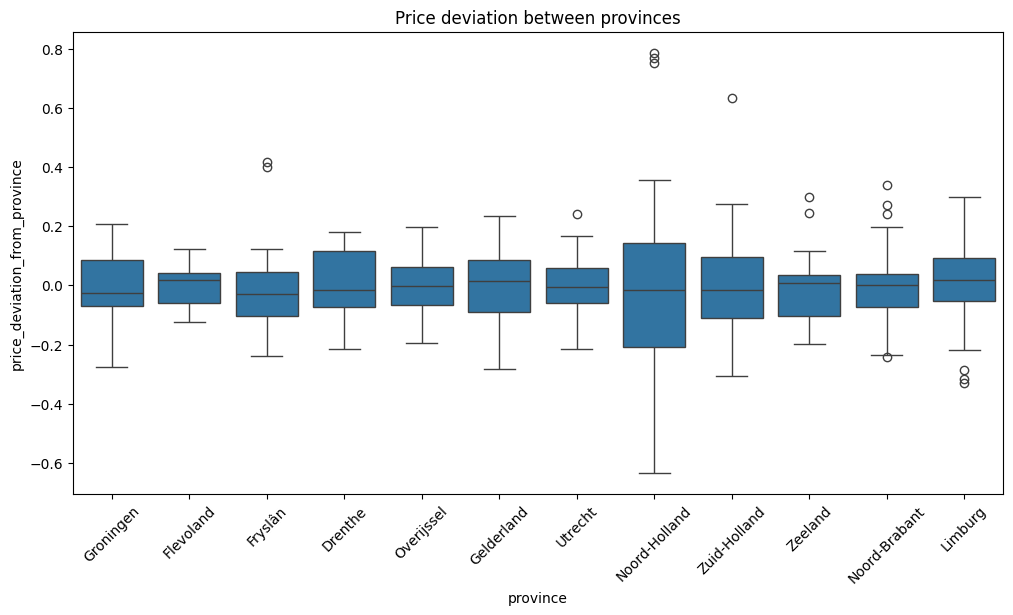

In [11]:
#########################################################################
# 8.8. Abweichungen realer Preise zwischen Provinzebene und Gemeindeebene
#########################################################################

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Daten laden

df = pd.read_csv("../data_clean/df_model_prepared.csv")
df_geo = pd.read_csv("../data_clean/df_geo_2023.csv")

# Merge – KEINE Suffixe nötig, da df KEINE province-Spalte hat
df = df.merge(
    df_geo[["municipality_code", "province"]],
    on="municipality_code",
    how="left"
)

# Durchschnittlicher Preis pro Provinz
province_means = df.groupby("province")["log_price_total"].mean()

# Abweichung je Gemeinde
df["price_deviation_from_province"] = (
    df["log_price_total"] - df["province"].map(province_means)
)

# Plot
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="province", y="price_deviation_from_province")
plt.xticks(rotation=45)
plt.title("Price deviation between provinces")
plt.show()


In [12]:
print(df.shape)
df["municipality_code"].nunique()

(341, 67)


341

Gefundene EGW-Spalten: ['share_egw', 'share_egw_geo']


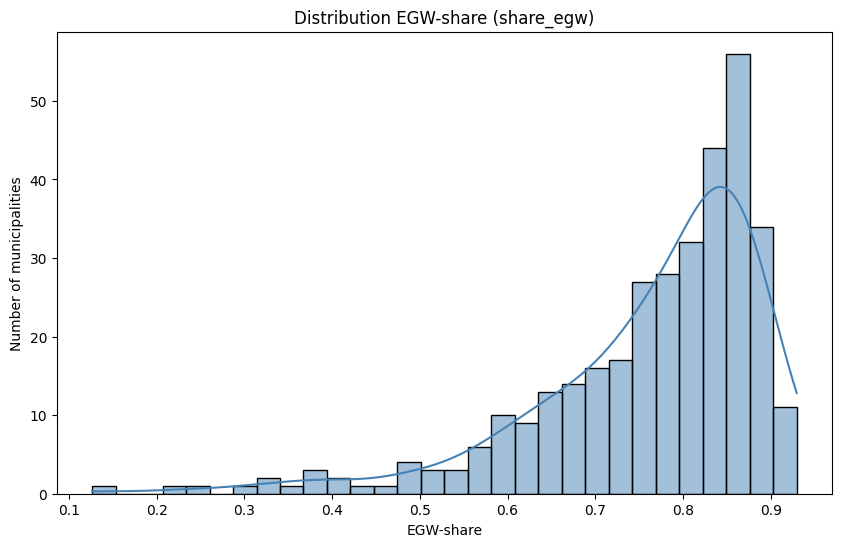

In [13]:
###################################################
# 8.9. Analyse der Differenzen zwischen EGW und MGW
###################################################

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Daten laden
df = pd.read_csv("../data_clean/df_model_prepared.csv")
df_geo = pd.read_csv("../data_clean/df_geo_2023.csv")

# Merge
df = df.merge(
    df_geo[["municipality_code", "share_egw", "share_mgw"]],
    on="municipality_code",
    how="left",
    suffixes=("", "_geo")
)

# Automatisch die richtige Spalte finden
egw_cols = [c for c in df.columns if "share_egw" in c]
print("Gefundene EGW-Spalten:", egw_cols)

# Erste passende Spalte verwenden
egw_col = egw_cols[0]

# Ein Eintrag pro Gemeinde
df_gemeenten = df.drop_duplicates(subset="municipality_code")

# df speichern
df.to_csv("../data_clean/df_analysis_base.csv", index=False)

# Histogramm
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df_gemeenten[egw_col], bins=30, kde=True, color="steelblue")
plt.title(f"Distribution EGW-share ({egw_col})")
plt.xlabel("EGW-share")
plt.ylabel("Number of municipalities")
plt.show()



In [14]:
print(df.shape)
print(df["municipality_code"].nunique())


(341, 67)
341


Gefundene EGW-Spalten: ['share_egw_x', 'share_egw_y']


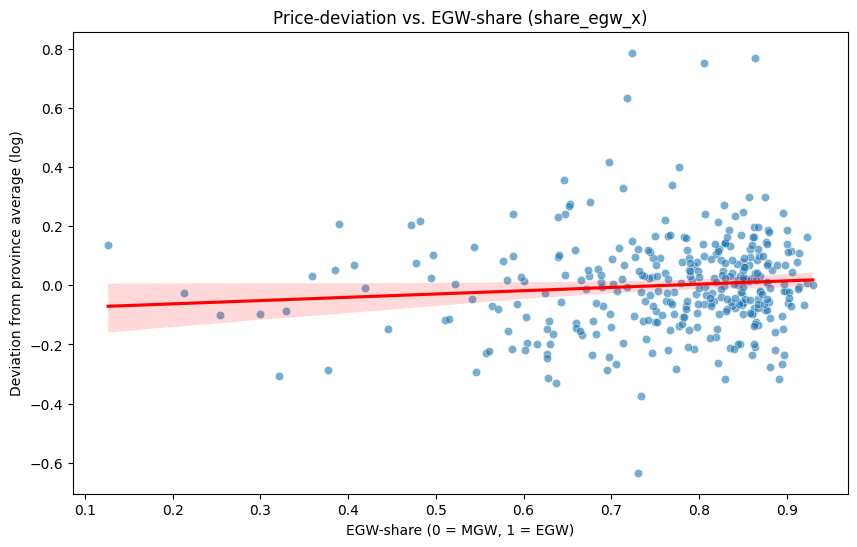

In [15]:
# EGW Preisabweichung

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Daten laden
df = pd.read_csv("../data_clean/df_model_prepared.csv")
df_geo = pd.read_csv("../data_clean/df_geo_2023.csv")

# 2. Merge: wir brauchen province + EGW-Anteile
df = df.merge(
    df_geo[["municipality_code", "province", "share_egw", "share_mgw"]],
    on="municipality_code",
    how="left"
)

# 3. Provinzmittel der log-Preise
province_means = df.groupby("province")["log_price_total"].mean()

# 4. Abweichung je Gemeinde
df["price_deviation_from_province"] = (
    df["log_price_total"] - df["province"].map(province_means)
)

# 5. Ein Eintrag pro Gemeinde
df_gemeenten = df.drop_duplicates(subset="municipality_code")

# 6. passende EGW-Spalte wählen
egw_cols = [c for c in df_gemeenten.columns if "share_egw" in c]
print("Gefundene EGW-Spalten:", egw_cols)
egw_col = egw_cols[0]

# 7. Scatterplot
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_gemeenten,
    x=egw_col,
    y="price_deviation_from_province",
    alpha=0.6
)
sns.regplot(
    data=df_gemeenten,
    x=egw_col,
    y="price_deviation_from_province",
    scatter=False,
    color="red"
)
plt.title(f"Price-deviation vs. EGW-share ({egw_col})")
plt.xlabel("EGW-share (0 = MGW, 1 = EGW)")
plt.ylabel("Deviation from province average (log)")
plt.show()


In [16]:
print(df.shape)
print(df["municipality_code"].nunique())

(341, 69)
341


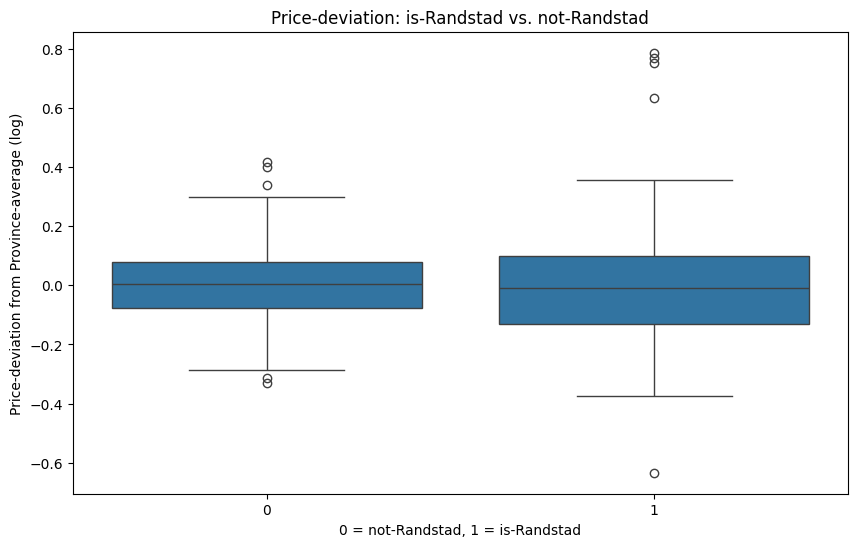

In [17]:
# Boxplot: Randstad vs. Nicht‑Randstad

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_gemeenten,
    x="is_randstad",
    y="price_deviation_from_province"
)
plt.title("Price-deviation: is-Randstad vs. not-Randstad")
plt.xlabel("0 = not-Randstad, 1 = is-Randstad")
plt.ylabel("Price-deviation from Province-average (log)")
plt.show()


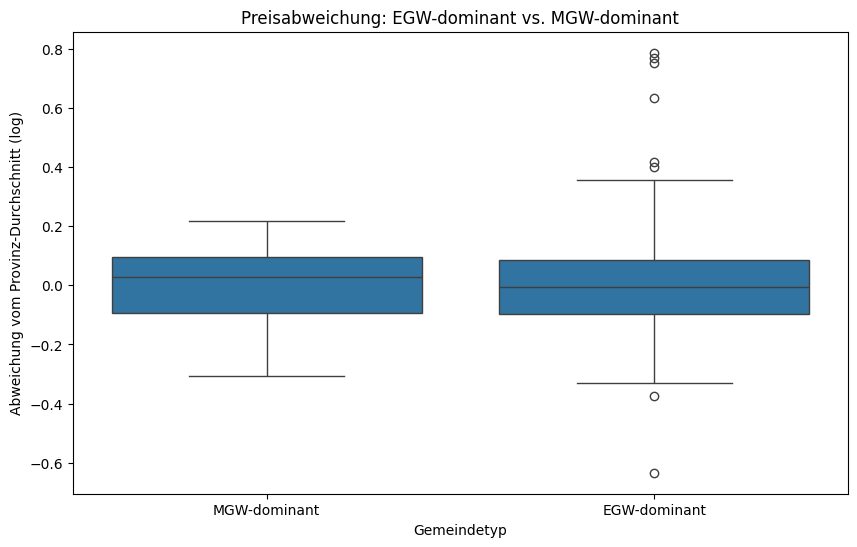

In [18]:
# EGW vs. MGW – Preisabweichungen getrennt darstellen

#df_gemeenten["type"] = df_gemeenten["share_egw"].apply(
#    lambda x: "EGW-dominant" if x > 0.5 else "MGW-dominant"
#)
#
#plt.figure(figsize=(10,6))
#sns.boxplot(
#    data=df_gemeenten,
#    x="type",
#    y="price_deviation_from_province"
#)
#plt.title("Preisabweichung: EGW-dominant vs. MGW-dominant")
#plt.xlabel("Gemeindetyp")
#plt.ylabel("Abweichung vom Provinz-Durchschnitt (log)")
#plt.show()


# EGW vs. MGW – Preisabweichungen getrennt darstellen

# richtige EGW-Spalte bestimmen
egw_cols = [c for c in df_gemeenten.columns if "share_egw" in c]
egw_col = egw_cols[0]   # das ist 'share_egw_geo'

df_gemeenten = df_gemeenten.copy()
df_gemeenten["type"] = df_gemeenten[egw_col].apply(
    lambda x: "EGW-dominant" if x > 0.5 else "MGW-dominant"
)

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_gemeenten,
    x="type",
    y="price_deviation_from_province"
)
plt.title("Preisabweichung: EGW-dominant vs. MGW-dominant")
plt.xlabel("Gemeindetyp")
plt.ylabel("Abweichung vom Provinz-Durchschnitt (log)")
plt.show()


<Figure size 1000x1000 with 0 Axes>

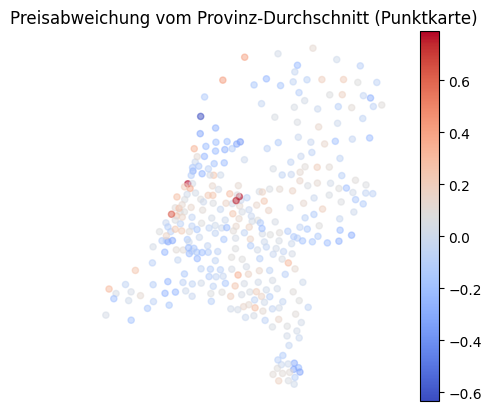

In [19]:
# Karte der Preisabweichungen

import geopandas as gpd
from shapely.geometry import Point

# Punkt-Geometrien erzeugen
df_geo["geometry"] = df_geo.apply(
    lambda row: Point(row["longitude"], row["latitude"]),
    axis=1
)

gdf = gpd.GeoDataFrame(df_geo, geometry="geometry", crs="EPSG:4326")

gdf = gdf.merge(
    df_gemeenten[[
        "municipality_code",
        "price_deviation_from_province",
        "share_mgw_y"
    ]],
    on="municipality_code",
    how="left"
)

plt.figure(figsize=(10,10))
gdf.plot(
    column="price_deviation_from_province",
    cmap="coolwarm",
    legend=True,
    markersize=20,
    alpha=0.5
)
plt.title("Preisabweichung vom Provinz-Durchschnitt (Punktkarte)")
plt.axis("off")
plt.show()


<Figure size 1000x1000 with 0 Axes>

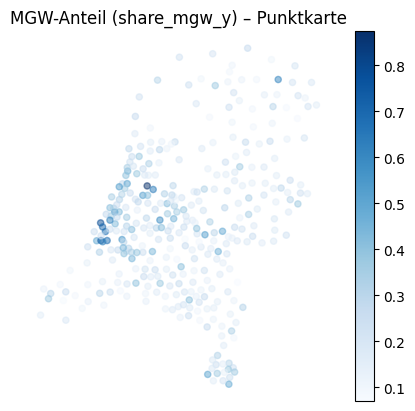

In [20]:
# MGW‑Cluster in der Randstad

import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. GeoDataFrame aus df_geo erzeugen (Punktgeometrien)
# ---------------------------------------------------------
df_geo["geometry"] = df_geo.apply(
    lambda row: Point(row["longitude"], row["latitude"]),
    axis=1
)

gdf = gpd.GeoDataFrame(df_geo, geometry="geometry", crs="EPSG:4326")

# ---------------------------------------------------------
# 2. Merge mit df_gemeenten (share_mgw + is_randstad)
#    Wichtig: df_gemeenten hat share_mgw, NICHT share_mgw_y
# ---------------------------------------------------------
gdf = gdf.merge(
    df_gemeenten[["municipality_code", "share_mgw_y", "is_randstad"]],
    on="municipality_code",
    how="left"
)

# ---------------------------------------------------------
# 3. MGW-Anteil als Punktkarte plotten
#    Wichtig: nach dem Merge heißt die Spalte share_mgw_y
# ---------------------------------------------------------
plt.figure(figsize=(10,10))
gdf.plot(
    column="share_mgw_y",
    cmap="Blues",
    legend=True,
    markersize=20,
    alpha=0.5
)
plt.title("MGW-Anteil (share_mgw_y) – Punktkarte")
plt.axis("off")
plt.show()


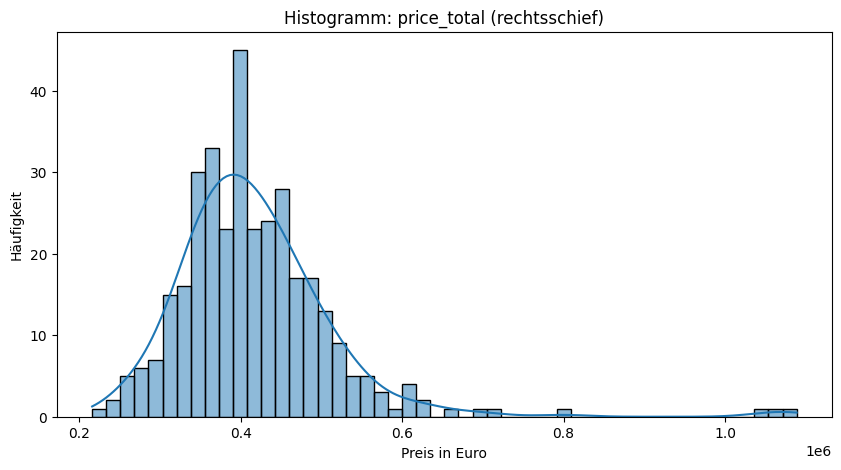

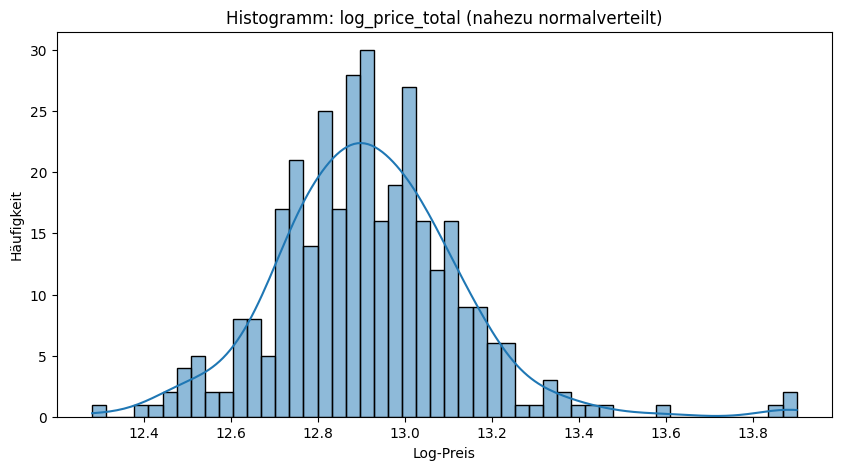

In [21]:
###########################################################
# 8.10. EXKURS: Vergleich price_totaal vs. log_price_totaal
###########################################################

# Histogramm 'price_totaal'

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df["price_total"], bins=50, kde=True)
plt.title("Histogramm: price_total (rechtsschief)")
plt.xlabel("Preis in Euro")
plt.ylabel("Häufigkeit")
plt.show()

# Histogramm 'log_price_totaal'

plt.figure(figsize=(10,5))
sns.histplot(df["log_price_total"], bins=50, kde=True)
plt.title("Histogramm: log_price_total (nahezu normalverteilt)")
plt.xlabel("Log-Preis")
plt.ylabel("Häufigkeit")
plt.show()
